✅ Project root set to: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/raw
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/processed
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/clustering
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/forecasting
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/evaluation
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/figures

✅ Configuration loaded successfully!
📁 Data will be read from: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/raw
📁 Outp

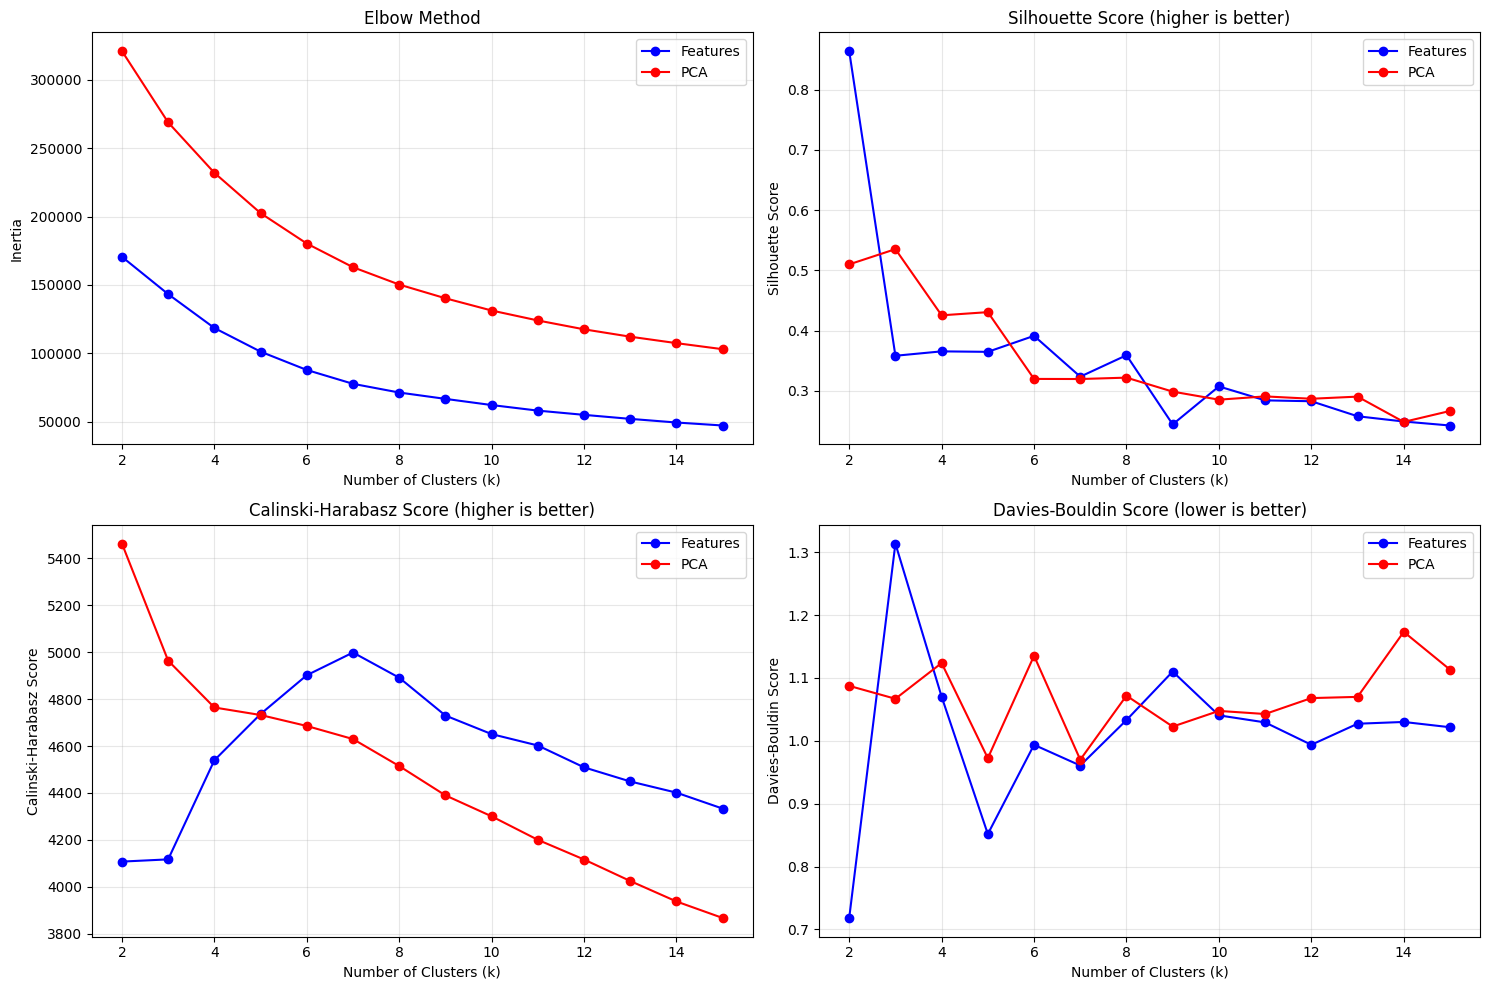


OPTIMAL K SELECTION

📊 Based on Silhouette Score:
   - Features: k=2
   - PCA: k=3

📊 Based on Davies-Bouldin Score:
   - Features: k=2
   - PCA: k=7

🎯 Selected k = 5 for final clustering

📊 Cluster Profiles:
                    ID                            mean                    \
                  mean           std  count       mean        std  count   
cluster                                                                    
0        153601.972964  87966.545517   5733  14.072622  13.654490   5733   
1        153296.862036  88331.840087  11561   6.874656   4.782044  11561   
2        146023.571429  90564.224215     84   0.587138   1.884384     84   
3         43713.000000           NaN      1   0.041614        NaN      1   
4        143948.875000  89340.566440    168   0.100623   0.554136    168   

                cv                    skewness  ... n_peaks peak_height_ratio  \
              mean       std  count       mean  ...   count              mean   
cluster           

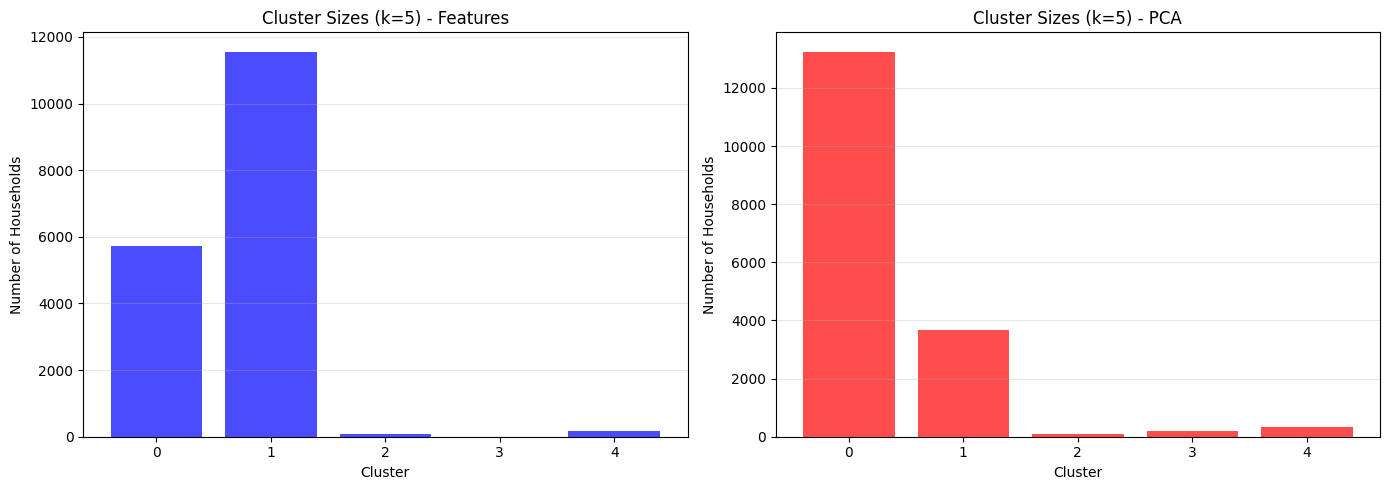

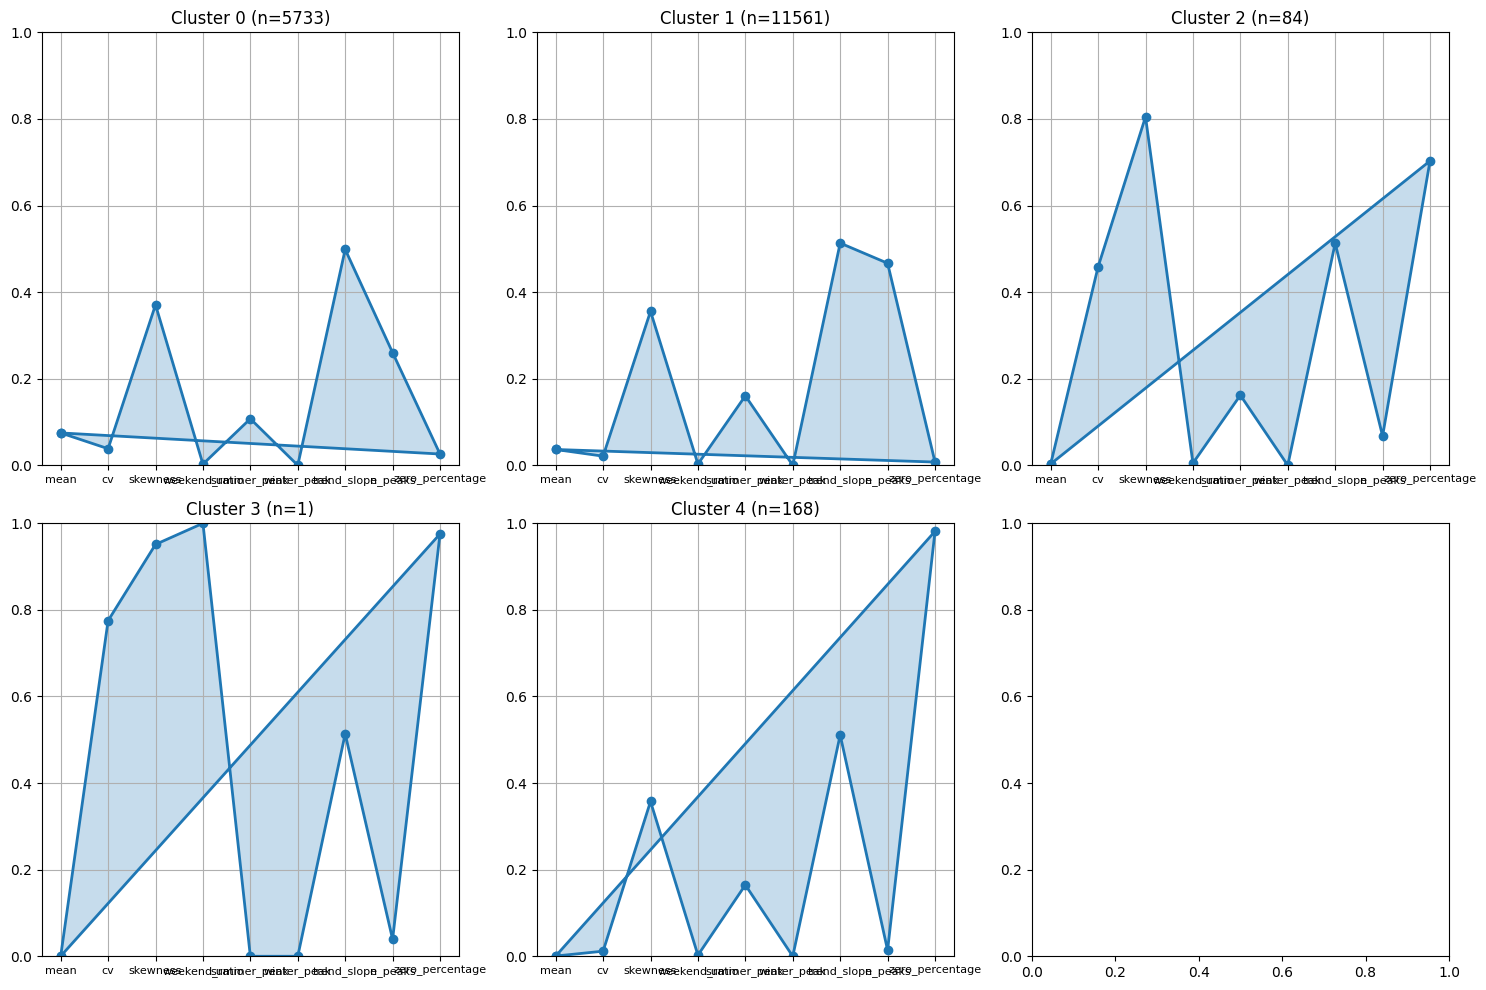


CLUSTER INTERPRETATION

📌 Cluster 0 (5733 households, 32.7%):
   Characteristics: high consumption, highly variable, decreasing trend
   Mean consumption: 14.07
   Zero percentage: 2.61%
   Summer/Winter ratio: 0.65 / 1.00

📌 Cluster 1 (11561 households, 65.9%):
   Characteristics: increasing trend
   Mean consumption: 6.87
   Zero percentage: 0.75%
   Summer/Winter ratio: 0.96 / 1.00

📌 Cluster 2 (84 households, 0.5%):
   Characteristics: low consumption, highly variable, 70.3% zeros, increasing trend
   Mean consumption: 0.59
   Zero percentage: 70.30%
   Summer/Winter ratio: 0.97 / 1.00

📌 Cluster 3 (1 households, 0.0%):
   Characteristics: low consumption, highly variable, 97.5% zeros, increasing trend
   Mean consumption: 0.04
   Zero percentage: 97.53%
   Summer/Winter ratio: 0.00 / 1.00

📌 Cluster 4 (168 households, 1.0%):
   Characteristics: low consumption, 98.1% zeros, decreasing trend
   Mean consumption: 0.10
   Zero percentage: 98.14%
   Summer/Winter ratio: 0.99 / 1.00



In [1]:
# %% [markdown]
# # Clustering Households by Energy Consumption Patterns 
# This notebook performs clustering on the extracted features to group similar households.

# %% [markdown]
# ## 1. Setup and Imports

# %%
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.config import (
    PROCESSED_DATA_DIR, FIGURES_DIR, CLUSTERING_OUTPUT_DIR,
    RANDOM_SEED, MIN_CLUSTERS, MAX_CLUSTERS
)

# Set random seed
np.random.seed(RANDOM_SEED)

# %% [markdown]
# ## 2. Load the Processed Features

# %%
# Load the normalized reduced features (13 selected features)
features_norm = pd.read_csv(PROCESSED_DATA_DIR / 'household_features_reduced_norm.csv')
print(f"✅ Loaded normalized features: {features_norm.shape}")

# Load PCA results (10 components)
pca_results = pd.read_csv(PROCESSED_DATA_DIR / 'pca_results.csv')
print(f"✅ Loaded PCA results: {pca_results.shape}")

# Extract feature columns (exclude ID)
feature_cols = [col for col in features_norm.columns if col != 'ID']
X_features = features_norm[feature_cols].values

# PCA columns
pca_cols = [col for col in pca_results.columns if col != 'ID']
X_pca = pca_results[pca_cols].values

print(f"\n📊 Feature matrix shape: {X_features.shape}")
print(f"📊 PCA matrix shape: {X_pca.shape}")

# %% [markdown]
# ## 3. Determine Optimal Number of Clusters

# %%
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# %%
# Function to compute clustering metrics
def evaluate_clustering(X, max_k=20):
    """Evaluate different numbers of clusters."""
    inertias = []
    silhouettes = []
    calinski_scores = []
    davies_scores = []
    
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
        labels = kmeans.fit_predict(X)
        
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))
        
        print(f"   k={k}: Silhouette={silhouettes[-1]:.3f}, "
              f"Calinski={calinski_scores[-1]:.1f}, "
              f"Davies={davies_scores[-1]:.3f}")
    
    return {
        'k': list(range(2, max_k + 1)),
        'inertia': inertias,
        'silhouette': silhouettes,
        'calinski': calinski_scores,
        'davies': davies_scores
    }

# %% [markdown]
# ### 3.1 Evaluate on Features

# %%
print("\n" + "="*60)
print("EVALUATING CLUSTERING ON 13 FEATURES")
print("="*60)
metrics_features = evaluate_clustering(X_features, max_k=15)

# %% [markdown]
# ### 3.2 Evaluate on PCA Components

# %%
print("\n" + "="*60)
print("EVALUATING CLUSTERING ON 10 PCA COMPONENTS")
print("="*60)
metrics_pca = evaluate_clustering(X_pca, max_k=15)

# %% [markdown]
# ### 3.3 Plot Metrics to Find Optimal k

# %%
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow method (inertia)
axes[0, 0].plot(metrics_features['k'], metrics_features['inertia'], 'bo-', label='Features')
axes[0, 0].plot(metrics_pca['k'], metrics_pca['inertia'], 'ro-', label='PCA')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Silhouette score
axes[0, 1].plot(metrics_features['k'], metrics_features['silhouette'], 'bo-', label='Features')
axes[0, 1].plot(metrics_pca['k'], metrics_pca['silhouette'], 'ro-', label='PCA')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (higher is better)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz score
axes[1, 0].plot(metrics_features['k'], metrics_features['calinski'], 'bo-', label='Features')
axes[1, 0].plot(metrics_pca['k'], metrics_pca['calinski'], 'ro-', label='PCA')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_title('Calinski-Harabasz Score (higher is better)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin score
axes[1, 1].plot(metrics_features['k'], metrics_features['davies'], 'bo-', label='Features')
axes[1, 1].plot(metrics_pca['k'], metrics_pca['davies'], 'ro-', label='PCA')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].set_title('Davies-Bouldin Score (lower is better)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clustering_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 3.4 Choose Optimal k

# %%
# Find best k according to each metric
best_k_silhouette_features = metrics_features['k'][np.argmax(metrics_features['silhouette'])]
best_k_silhouette_pca = metrics_pca['k'][np.argmax(metrics_pca['silhouette'])]

best_k_davies_features = metrics_features['k'][np.argmin(metrics_features['davies'])]
best_k_davies_pca = metrics_pca['k'][np.argmin(metrics_pca['davies'])]

print("\n" + "="*60)
print("OPTIMAL K SELECTION")
print("="*60)
print(f"\n📊 Based on Silhouette Score:")
print(f"   - Features: k={best_k_silhouette_features}")
print(f"   - PCA: k={best_k_silhouette_pca}")
print(f"\n📊 Based on Davies-Bouldin Score:")
print(f"   - Features: k={best_k_davies_features}")
print(f"   - PCA: k={best_k_davies_pca}")

# Choose a final k (you can adjust based on interpretation)
final_k = 5  # Based on PCA results and interpretability
print(f"\n🎯 Selected k = {final_k} for final clustering")

# %% [markdown]
# ## 4. Perform Final Clustering

# %%
# Fit K-means with final k on both datasets
kmeans_features = KMeans(n_clusters=final_k, random_state=RANDOM_SEED, n_init=10)
kmeans_pca = KMeans(n_clusters=final_k, random_state=RANDOM_SEED, n_init=10)

labels_features = kmeans_features.fit_predict(X_features)
labels_pca = kmeans_pca.fit_predict(X_pca)

# Add labels to dataframes
features_norm['cluster_features'] = labels_features
pca_results['cluster_pca'] = labels_pca

# %% [markdown]
# ## 5. Analyze Clusters

# %%
# Load original features for interpretation
original_features = pd.read_csv(PROCESSED_DATA_DIR / 'household_features_reduced.csv')

# Add cluster labels
original_features['cluster'] = labels_features

# Calculate cluster profiles
cluster_profiles = original_features.groupby('cluster').agg(['mean', 'std', 'count'])
print("\n📊 Cluster Profiles:")
print(cluster_profiles)

# %%
# Visualize cluster sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Features clustering
size_features = original_features['cluster'].value_counts().sort_index()
axes[0].bar(size_features.index, size_features.values, color='blue', alpha=0.7)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Households')
axes[0].set_title(f'Cluster Sizes (k={final_k}) - Features')
axes[0].grid(True, alpha=0.3, axis='y')

# PCA clustering
size_pca = pca_results['cluster_pca'].value_counts().sort_index()
axes[1].bar(size_pca.index, size_pca.values, color='red', alpha=0.7)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Households')
axes[1].set_title(f'Cluster Sizes (k={final_k}) - PCA')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 6. Visualize Cluster Characteristics

# %%
# Select key features for visualization
key_features = ['mean', 'cv', 'skewness', 'weekend_ratio', 
                'summer_peak', 'winter_peak', 'trend_slope',
                'n_peaks', 'zero_percentage']

# Create radar charts for each cluster
from math import pi

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Normalize features for radar chart
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
features_radar = scaler_radar.fit_transform(original_features[key_features])

for cluster in range(final_k):
    # Get cluster members
    cluster_mask = original_features['cluster'] == cluster
    cluster_means = np.mean(features_radar[cluster_mask], axis=0)
    
    # Create radar chart
    ax = axes[cluster]
    angles = [n / len(key_features) * 2 * pi for n in range(len(key_features))]
    angles += angles[:1]
    
    values = cluster_means.tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(key_features, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster} (n={size_features[cluster]})')
    ax.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_radar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 7. Cluster Interpretation

# %%
print("\n" + "="*60)
print("CLUSTER INTERPRETATION")
print("="*60)

for cluster in range(final_k):
    print(f"\n📌 Cluster {cluster} ({size_features[cluster]} households, {size_features[cluster]/len(original_features)*100:.1f}%):")
    
    # Get mean values for this cluster
    cluster_data = original_features[original_features['cluster'] == cluster]
    means = cluster_data[key_features].mean()
    
    # Describe the cluster
    desc = []
    if means['mean'] > original_features['mean'].quantile(0.75):
        desc.append("high consumption")
    elif means['mean'] < original_features['mean'].quantile(0.25):
        desc.append("low consumption")
    
    if means['cv'] > original_features['cv'].quantile(0.75):
        desc.append("highly variable")
    
    if means['zero_percentage'] > 10:
        desc.append(f"{means['zero_percentage']:.1f}% zeros")
    
    if means['summer_peak'] > 1.1:
        desc.append("summer peak")
    if means['winter_peak'] > 1.1:
        desc.append("winter peak")
    
    if means['trend_slope'] > 0:
        desc.append("increasing trend")
    elif means['trend_slope'] < 0:
        desc.append("decreasing trend")
    
    if means['n_peaks'] > original_features['n_peaks'].quantile(0.75):
        desc.append("many peaks")
    
    print(f"   Characteristics: {', '.join(desc) if desc else 'average'}")
    print(f"   Mean consumption: {means['mean']:.2f}")
    print(f"   Zero percentage: {means['zero_percentage']:.2f}%")
    print(f"   Summer/Winter ratio: {means['summer_peak']:.2f} / {means['winter_peak']:.2f}")

# %% [markdown]
# ## 8. Compare Features vs PCA Clustering

# %%
# Check agreement between feature-based and PCA-based clustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(labels_features, labels_pca)
nmi = normalized_mutual_info_score(labels_features, labels_pca)

print("\n" + "="*60)
print("CLUSTERING COMPARISON")
print("="*60)
print(f"\n📊 Agreement between Feature-based and PCA clustering:")
print(f"   - Adjusted Rand Index: {ari:.3f} (0 = random, 1 = perfect match)")
print(f"   - Normalized Mutual Info: {nmi:.3f}")

if ari > 0.7:
    print("   ✅ High agreement - both approaches find similar structures")
elif ari > 0.4:
    print("   📊 Moderate agreement - some overlap but differences")
else:
    print("   🔍 Low agreement - approaches capture different patterns")

# %% [markdown]
# ## 9. Save Results

# %%
# Save cluster assignments
original_features.to_csv(CLUSTERING_OUTPUT_DIR / 'cluster_assignments_features.csv', index=False)
pca_results.to_csv(CLUSTERING_OUTPUT_DIR / 'cluster_assignments_pca.csv', index=False)

# Save cluster profiles
cluster_profiles.to_csv(CLUSTERING_OUTPUT_DIR / 'cluster_profiles.csv')

# Save clustering model
import joblib
joblib.dump(kmeans_features, CLUSTERING_OUTPUT_DIR / 'kmeans_features_model.pkl')
joblib.dump(kmeans_pca, CLUSTERING_OUTPUT_DIR / 'kmeans_pca_model.pkl')

print(f"\n✅ All clustering results saved to: {CLUSTERING_OUTPUT_DIR}")

# %% [markdown]
# ## 10. Summary

# %%
print("\n" + "="*60)
print("CLUSTERING SUMMARY")
print("="*60)
print(f"\n📊 Dataset: {len(original_features)} households")
print(f"📊 Number of clusters: {final_k}")
print(f"\n📈 Cluster sizes:")
for cluster in range(final_k):
    size = size_features[cluster]
    pct = size/len(original_features)*100
    print(f"   Cluster {cluster}: {size} households ({pct:.1f}%)")

print(f"\n📊 Agreement between methods (ARI): {ari:.3f}")
print(f"\n✅ Results saved to: {CLUSTERING_OUTPUT_DIR}")
print("\n" + "="*60)
print("CLUSTERING COMPLETE")
print("="*60)